In [1]:
# Import all required packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load the dataset
df = pd.read_excel("C:/Users/b7019/OneDrive/Desktop/final yr project/dataset/mobile_data.xlsx")

# Quick checks
print("Shape of dataset:", df.shape)
print("Column names:", df.columns.tolist())
print("Missing values per column:\n", df.isnull().sum())
print("Number of duplicate rows:", df.duplicated().sum())

# Preview first 5 rows
df.head()

Shape of dataset: (1000, 10)
Column names: ['User_ID', 'Age', 'Gender', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 'Number_of_Apps_Used', 'Social_Media_Usage_Hours', 'Productivity_App_Usage_Hours', 'Gaming_App_Usage_Hours', 'Location']
Missing values per column:
 User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64
Number of duplicate rows: 0


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,Male,2.61,7.15,24,4.43,0.55,2.40,Los Angeles
1,2,46,Male,2.13,13.79,18,4.67,4.42,2.43,Chicago
2,3,32,Female,7.28,4.50,11,4.58,1.71,2.83,Houston
3,4,25,Female,1.20,6.29,21,3.18,3.42,4.58,Phoenix
4,5,38,Male,6.31,12.59,14,3.15,0.13,4.00,New York


In [4]:
# Encode categorical columns
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Location'] = label_encoder.fit_transform(df['Location'])

print("Categorical columns encoded.")
df.head()

Categorical columns encoded.


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,1,2.61,7.15,24,4.43,0.55,2.40,2
1,2,46,1,2.13,13.79,18,4.67,4.42,2.43,0
2,3,32,0,7.28,4.50,11,4.58,1.71,2.83,1
3,4,25,0,1.20,6.29,21,3.18,3.42,4.58,4
4,5,38,1,6.31,12.59,14,3.15,0.13,4.00,3


In [5]:
# Select numerical columns to scale
cols_to_scale = [
    'Total_App_Usage_Hours',
    'Daily_Screen_Time_Hours',
    'Number_of_Apps_Used',
    'Social_Media_Usage_Hours',
    'Productivity_App_Usage_Hours',
    'Gaming_App_Usage_Hours'
]

scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Numerical features scaled.")
df.head()

Numerical features scaled.


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,1,0.146764,0.472671,0.807692,0.887776,0.110,0.478958,2
1,2,46,1,0.103008,0.983834,0.576923,0.935872,0.884,0.484970,0
2,3,32,0,0.572470,0.268668,0.307692,0.917836,0.342,0.565130,1
3,4,25,0,0.018232,0.406467,0.692308,0.637275,0.684,0.915832,4
4,5,38,1,0.484047,0.891455,0.423077,0.631263,0.026,0.799599,3


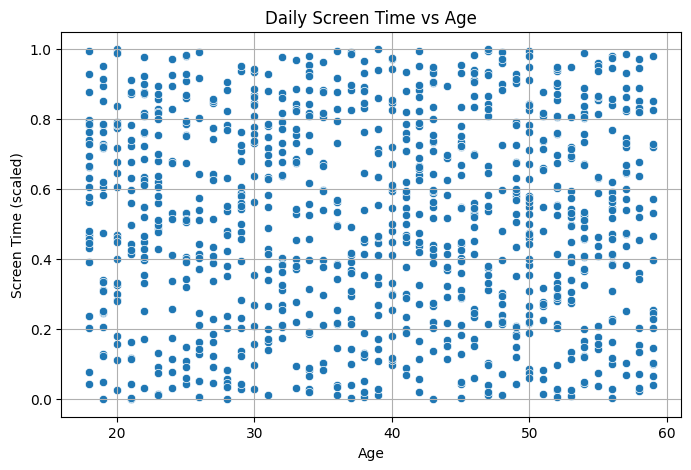

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Daily_Screen_Time_Hours', data=df)
plt.title('Daily Screen Time vs Age')
plt.xlabel('Age')
plt.ylabel('Screen Time (scaled)')
plt.grid(True)
plt.show()

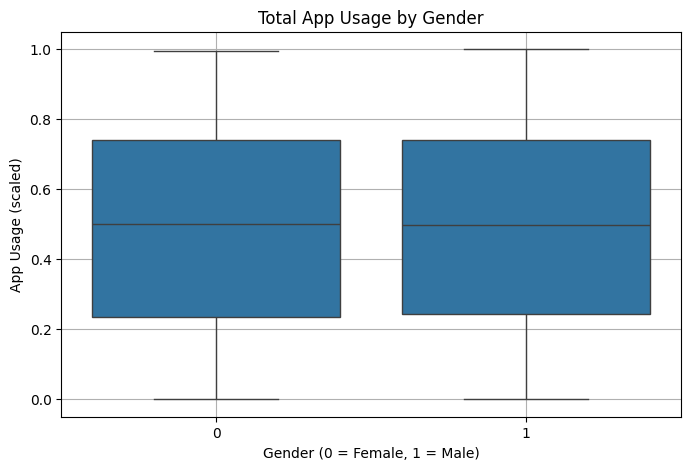

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Total_App_Usage_Hours', data=df)
plt.title('Total App Usage by Gender')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('App Usage (scaled)')
plt.grid(True)
plt.show()

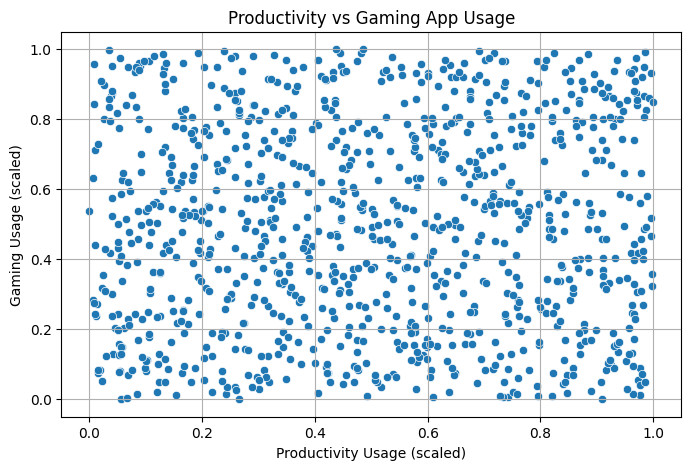

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Productivity_App_Usage_Hours', y='Gaming_App_Usage_Hours', data=df)
plt.title('Productivity vs Gaming App Usage')
plt.xlabel('Productivity Usage (scaled)')
plt.ylabel('Gaming Usage (scaled)')
plt.grid(True)
plt.show()

In [9]:
from sklearn.cluster import KMeans

# Select features for clustering
X = df[['Total_App_Usage_Hours','Daily_Screen_Time_Hours',
        'Number_of_Apps_Used','Social_Media_Usage_Hours',
        'Productivity_App_Usage_Hours','Gaming_App_Usage_Hours']]

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

print("Clustering complete. Cluster labels added to dataframe.")

Clustering complete. Cluster labels added to dataframe.


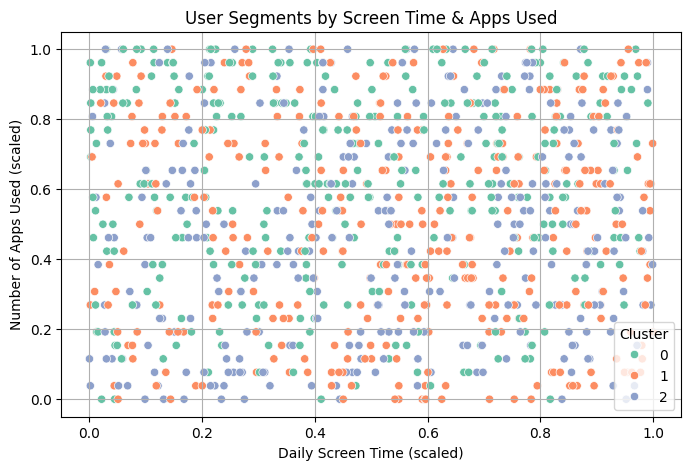

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Daily_Screen_Time_Hours', y='Number_of_Apps_Used', hue='Cluster', data=df, palette='Set2')
plt.title("User Segments by Screen Time & Apps Used")
plt.xlabel("Daily Screen Time (scaled)")
plt.ylabel("Number of Apps Used (scaled)")
plt.grid(True)
plt.show()

In [11]:
cluster_summary = df.groupby('Cluster')[X.columns].mean()
print("Cluster Profiles:\n", cluster_summary)

Cluster Profiles:
          Total_App_Usage_Hours  Daily_Screen_Time_Hours  Number_of_Apps_Used  \
Cluster                                                                        
0                     0.362456                 0.466877             0.608258   
1                     0.573043                 0.548451             0.499672   
2                     0.544877                 0.529008             0.461663   

         Social_Media_Usage_Hours  Productivity_App_Usage_Hours  \
Cluster                                                           
0                        0.477761                      0.406194   
1                        0.422658                      0.789301   
2                        0.587779                      0.269851   

         Gaming_App_Usage_Hours  
Cluster                          
0                      0.746522  
1                      0.439703  
2                      0.277523  


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Features and target
X = df[['Age','Gender','Number_of_Apps_Used','Social_Media_Usage_Hours','Productivity_App_Usage_Hours','Gaming_App_Usage_Hours']]
y = df['Daily_Screen_Time_Hours']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 0.08386872207592866


In [13]:
feature_importance = pd.Series(model.coef_, index=X.columns)
print("Feature Importance:\n", feature_importance.sort_values(ascending=False))

Feature Importance:
 Productivity_App_Usage_Hours    0.044340
Social_Media_Usage_Hours        0.035678
Gender                          0.016416
Number_of_Apps_Used            -0.000691
Age                            -0.000743
Gaming_App_Usage_Hours         -0.014534
dtype: float64


In [14]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

            User_ID        Age    Gender  Total_App_Usage_Hours  \
Cluster                                                           
0        495.285294  38.938235  0.517647               0.362456   
1        507.971591  38.744318  0.556818               0.573043   
2        497.717532  38.532468  0.470779               0.544877   

         Daily_Screen_Time_Hours  Number_of_Apps_Used  \
Cluster                                                 
0                       0.466877             0.608258   
1                       0.548451             0.499672   
2                       0.529008             0.461663   

         Social_Media_Usage_Hours  Productivity_App_Usage_Hours  \
Cluster                                                           
0                        0.477761                      0.406194   
1                        0.422658                      0.789301   
2                        0.587779                      0.269851   

         Gaming_App_Usage_Hours  Location 

C:\Users\b7019\AppData\Local\Temp\ipykernel_9844\2548321418.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


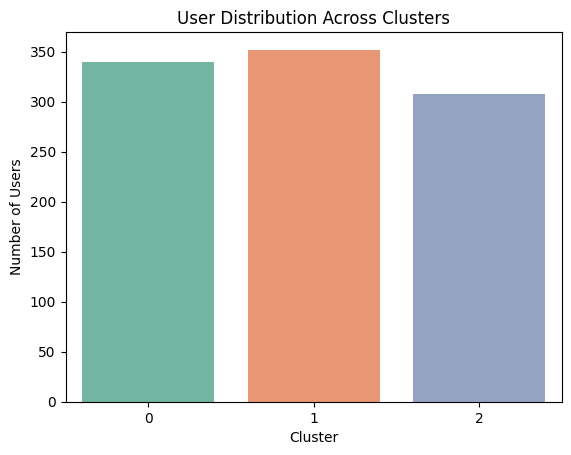

In [15]:
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title("User Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.show()

In [16]:
feature_importance = pd.Series(model.coef_, index=X.columns)
print(feature_importance.sort_values(ascending=False))

Productivity_App_Usage_Hours    0.044340
Social_Media_Usage_Hours        0.035678
Gender                          0.016416
Number_of_Apps_Used            -0.000691
Age                            -0.000743
Gaming_App_Usage_Hours         -0.014534
dtype: float64


In [17]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: -0.013464111853273895


In [18]:
print("R² Score:", model.score(X_test, y_test))

R² Score: -0.007710709106603542


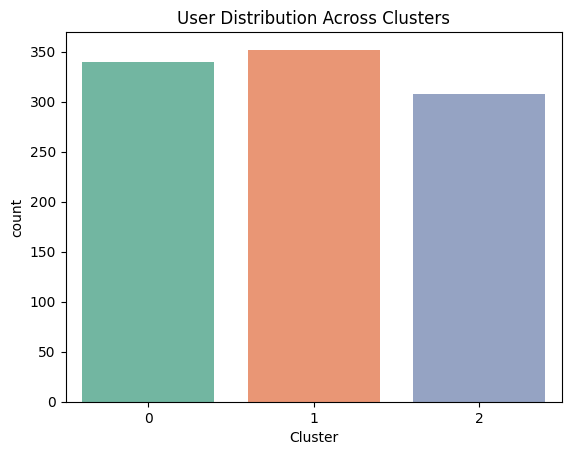

In [19]:
sns.countplot(x='Cluster', hue='Cluster', data=df, palette='Set2', legend=False)
plt.title("User Distribution Across Clusters")
plt.show()

C:\Users\b7019\AppData\Local\Temp\ipykernel_9844\3868505846.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Daily_Screen_Time_Hours', data=df, palette='Set3')


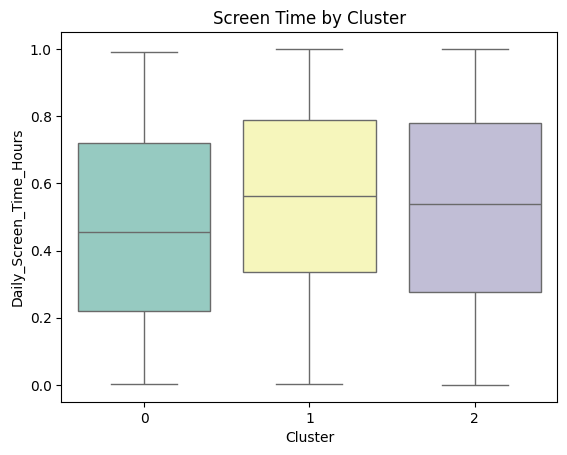

In [20]:
sns.boxplot(x='Cluster', y='Daily_Screen_Time_Hours', data=df, palette='Set3')
plt.title("Screen Time by Cluster")
plt.show()

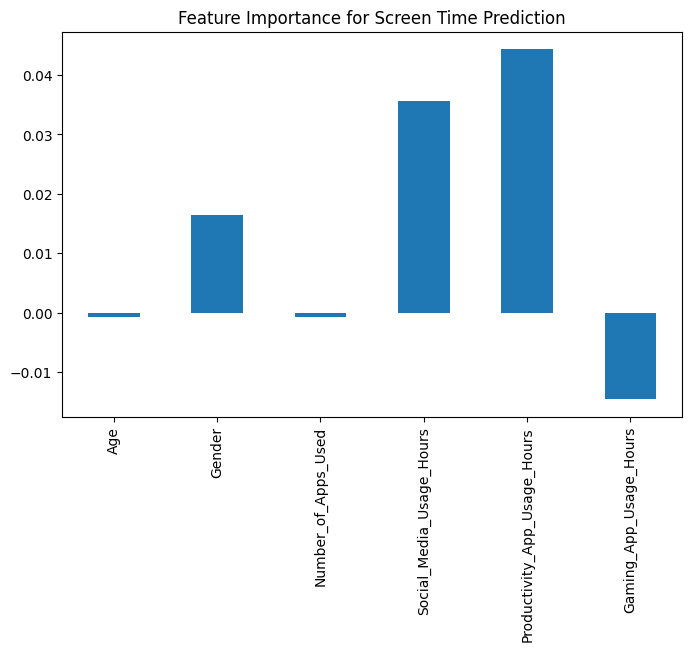

In [21]:
feature_importance.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance for Screen Time Prediction")
plt.show()